# **DYNAMIC ENVIRONMENT SETUP**

In [1]:
import kagglehub
dhoogla_cicids2017_path = kagglehub.dataset_download('dhoogla/cicids2017')

print('Data source import complete.')

Data source import complete.


In [2]:
import os, random, warnings

# 1) GPU/TPU CONFIGURATION
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF info messages
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import pandas as pd
import numpy as np

# Improved hardware detection
try:
    # First try TPU detection
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    device_type = 'TPU'
    print(f"✅ Using TPU: {tpu.master()}")
except (ValueError, tf.errors.NotFoundError):
    # If TPU not found, check for GPUs
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Use all available GPUs
        strategy = tf.distribute.MirroredStrategy()
        device_type = 'GPU'
        print(f"✅ Using {len(gpus)} GPU(s)")
    else:
        # Fallback to CPU
        strategy = tf.distribute.get_strategy()
        device_type = 'CPU'
        print("✅ Using CPU")

print("Visible devices:", tf.config.get_visible_devices())

# 2) PRECISION CONFIGURATION
from tensorflow.keras import mixed_precision

if device_type == 'TPU':
    policy = mixed_precision.Policy('mixed_bfloat16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_bfloat16 (required for TPU)")
elif any('gpu' in d.device_type.lower() for d in tf.config.get_visible_devices()):
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_float16")
else:
    print("✅ Precision: float32 (CPU mode)")

# 3) GPU MEMORY MANAGEMENT (skip for TPU)
if device_type == 'GPU':
    for gpu in tf.config.list_physical_devices('GPU'):
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

    
# 4) PERFORMANCE OPTIMIZATIONS
# Enable XLA compilation
tf.config.optimizer.set_jit(True)

# Configure dataset pipeline
options = tf.data.Options()
options.experimental_optimization.parallel_batch = True
options.threading.private_threadpool_size = min(8, os.cpu_count() or 8)

# 5) REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── PYDATA & ML LIBRARIES ─────────────────────────────────────────────────────

from sklearn.model_selection      import train_test_split
from sklearn.feature_selection    import VarianceThreshold, SelectFromModel
from sklearn.ensemble             import RandomForestClassifier
from sklearn.preprocessing        import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.decomposition        import PCA
from sklearn.utils                import resample, class_weight
from sklearn.metrics              import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.manifold             import TSNE

# Optional UMAP embedding
try:
    from umap import UMAP
    print("✅ UMAP imported")
except ImportError:
    print("⚠️ UMAP not available")

# ─── DEEP LEARNING UTILITIES ───────────────────────────────────────────────────
from tensorflow.keras             import layers, models, optimizers, callbacks
from tensorflow.data              import Dataset
from tensorflow.python.framework  import convert_to_constants

# ─── IMAGE / AUTOENCODER METRICS ───────────────────────────────────────────────
# Correct installation and import of scikit-image
try:
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image metrics imported")
except ImportError:
    print("Installing scikit-image for image metrics...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image installed and imported")

# ─── PLOTTING ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

print(f"✅ Environment configured | TensorFlow {tf.__version__} | Device: {device_type}")

2026-03-26 13:28:50.892847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774531731.145987      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774531731.208152      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1774531745.688863      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Using 1 GPU(s)
Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Precision: mixed_float16
✅ UMAP imported
✅ scikit-image metrics imported
✅ Environment configured | TensorFlow 2.18.0 | Device: GPU


# **Data Loading**

In [3]:
import json
import joblib
# Load data (as in the prompt)
BASE_PATH = "/kaggle/input/notebooks/yacermeftah/cicids-dataset-processing/cicids2017_processed"
with open(f"{BASE_PATH}/manifest.json") as f:
    manifest = json.load(f)

train_df = pd.read_parquet(f"{BASE_PATH}/data/train_processed.parquet")
test_df  = pd.read_parquet(f"{BASE_PATH}/data/test_processed.parquet")

In [4]:
X_train_raw = train_df.drop(columns=["LabelEncoded"])
y_train = train_df["LabelEncoded"].values

X_test_raw = test_df.drop(columns=["LabelEncoded"])
y_test = test_df["LabelEncoded"].values

In [5]:
scaler = joblib.load(f"{BASE_PATH}/artifacts/scaler.joblib")
X_train_scaled = scaler.transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

In [6]:
Label_Encoder = joblib.load(f"{BASE_PATH}/artifacts/label_encoder.joblib")

with open(f"{BASE_PATH}/artifacts//preprocess_settings.json") as f:
    settings = json.load(f)

In [7]:
feature_names = settings["feature_selection"]["selected_features"]
labels = list(settings["label_mapping"].keys())

In [8]:
# Train/validation split (multi‑class, stratified)
SEED = 42
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)
    
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (1480781, 34), Val: (370196, 34)


# **Modeling**

In [9]:
import os
import json
import joblib
import numpy as np
import tensorflow as tf
from tensorflow import keras as tfk
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb

In [10]:
class Sampling(tfk.layers.Layer):
    def __init__(self, kl_weight=1.0, kl_multiplier=0.01, **kwargs):
        super().__init__(**kwargs)
        self.kl_weight = tf.Variable(
            initial_value=float(kl_weight),
            trainable=False,
            dtype=tf.float32
        )
        self.kl_multiplier = kl_multiplier

    def call(self, inputs, training=None):
        z_mean, z_log_var = inputs
        z_mean = tf.cast(z_mean, tf.float32)
        z_log_var = tf.cast(z_log_var, tf.float32)
        z_log_var = tf.clip_by_value(z_log_var, -20.0, 10.0)

        # KL loss (always computed)
        kl_element = -0.5 * (1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_element, axis=1))
        self.add_loss(self.kl_weight * self.kl_multiplier * kl_loss)

        # Stochastic during training, deterministic otherwise
        if training:
            eps = tf.random.normal(tf.shape(z_mean), dtype=tf.float32)
            return z_mean + tf.exp(0.5 * z_log_var) * eps
        else:
            return z_mean

In [11]:
class VAE(tfk.Model):
    def __init__(self, input_dim, latent_dim=16, beta=0.1, **kwargs):
        super().__init__(**kwargs)
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_dense0 = tfk.layers.Dense(256)
        self.encoder_bn0    = tfk.layers.BatchNormalization()
        self.encoder_act0   = tfk.layers.LeakyReLU()

        self.encoder_dense1 = tfk.layers.Dense(128)
        self.encoder_bn1    = tfk.layers.BatchNormalization()
        self.encoder_act1   = tfk.layers.LeakyReLU()

        self.encoder_dense2 = tfk.layers.Dense(64)
        self.encoder_bn2    = tfk.layers.BatchNormalization()
        self.encoder_act2   = tfk.layers.LeakyReLU()

        self.z_mean_layer    = tfk.layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = tfk.layers.Dense(latent_dim, name="z_log_var")
        self.sampling        = Sampling(kl_multiplier=beta, name="sampling")

        # Decoder
        self.decoder_dense1 = tfk.layers.Dense(64)
        self.decoder_bn1    = tfk.layers.BatchNormalization()
        self.decoder_act1   = tfk.layers.LeakyReLU()

        self.decoder_dense2 = tfk.layers.Dense(128)
        self.decoder_bn2    = tfk.layers.BatchNormalization()
        self.decoder_act2   = tfk.layers.LeakyReLU()

        self.decoder_dense3 = tfk.layers.Dense(256)
        self.decoder_bn3    = tfk.layers.BatchNormalization()
        self.decoder_act3   = tfk.layers.LeakyReLU()

        self.decoder_output = tfk.layers.Dense(input_dim, activation="linear", name="decoder_output")

    def call(self, inputs, training=None):
        # Encoder
        x = self.encoder_dense0(inputs)
        x = self.encoder_bn0(x, training=training)
        x = self.encoder_act0(x)

        x = self.encoder_dense1(x)
        x = self.encoder_bn1(x, training=training)
        x = self.encoder_act1(x)

        x = self.encoder_dense2(x)
        x = self.encoder_bn2(x, training=training)
        x = self.encoder_act2(x)

        z_mean    = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)
        z         = self.sampling((z_mean, z_log_var), training=training)

        # Decoder
        x = self.decoder_dense1(z)
        x = self.decoder_bn1(x, training=training)
        x = self.decoder_act1(x)

        x = self.decoder_dense2(x)
        x = self.decoder_bn2(x, training=training)
        x = self.decoder_act2(x)

        x = self.decoder_dense3(x)
        x = self.decoder_bn3(x, training=training)
        x = self.decoder_act3(x)

        return self.decoder_output(x)

    def encode(self, inputs, training=False):
        x = self.encoder_dense0(inputs)
        x = self.encoder_bn0(x, training=training)
        x = self.encoder_act0(x)

        x = self.encoder_dense1(x)
        x = self.encoder_bn1(x, training=training)
        x = self.encoder_act1(x)

        x = self.encoder_dense2(x)
        x = self.encoder_bn2(x, training=training)
        x = self.encoder_act2(x)

        z_mean = self.z_mean_layer(x)
        return z_mean
        
    def compile(self, optimizer, loss_fn, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer
        self.loss_fn = loss_fn

        self.total_loss_tracker = tfk.metrics.Mean(name="loss")
        self.rec_loss_tracker   = tfk.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker    = tfk.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.rec_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        x = data if not isinstance(data, tuple) else data[0]

        with tf.GradientTape() as tape:
            reconstruction = self(x, training=True)
            rec_loss = self.loss_fn(x, reconstruction)
            kl_loss = tf.add_n(self.losses) if self.losses else 0.0
            total_loss = rec_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.rec_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data if not isinstance(data, tuple) else data[0]
        reconstruction = self(x, training=False)
        rec_loss = self.loss_fn(x, reconstruction)
        kl_loss = tf.add_n(self.losses) if self.losses else 0.0
        total_loss = rec_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.rec_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [12]:
class HierarchicalVAEGatedSystem:
    """
    Revised design:
      - LightGBM is the main multiclass predictor.
      - VAEs are specialist reconstruction models.
      - A learned meta-gate decides whether to trust VAE, LightGBM, or abstain.
      - Class 7 can be treated as open-set / weakly supervised.
    """

    def __init__(
        self,
        input_dim,
        latent_dim=16,
        n_classes=9,
        seed=42,
        vae_beta=0.1,
        oversample_minority=True,
        open_set_class_ids=(7,),
        use_latents=False,
        augmentation_noise_std=0.01,
    ):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.n_classes = n_classes
        self.seed = seed
        self.vae_beta = vae_beta
        self.oversample_minority = oversample_minority
        self.open_set_class_ids = set(open_set_class_ids or [])
        self.use_latents = use_latents
        self.augmentation_noise_std = augmentation_noise_std

        self.vaes = {}          # class_id -> VAE model or None
        self.class_ids = None    # np.array of observed class IDs

        self.booster = None      # main multiclass LightGBM
        self.meta_gate = None    # 3-way gate: 0=LightGBM, 1=VAE, 2=abstain

    # --------------------------
    # Minority augmentation
    # --------------------------
    def _augment_class_data(self, X_class, target_samples):
        """
        Noise-augmented expansion instead of pure duplication.
        """
        X_class = X_class.astype(np.float32)
        if X_class.shape[0] >= target_samples:
            return X_class

        n_needed = target_samples - X_class.shape[0]
        idx = np.random.choice(X_class.shape[0], size=n_needed, replace=True)
        sampled = X_class[idx]
        noise = np.random.normal(
            loc=0.0,
            scale=self.augmentation_noise_std,
            size=sampled.shape
        ).astype(np.float32)

        augmented = sampled + noise
        return np.vstack([X_class, augmented]).astype(np.float32)

    # --------------------------
    # Train one VAE for one class
    # --------------------------
    def _train_vae_for_class(self, X_class, class_id, epochs=50, batch_size=256, val_split=0.2):
        print(f"Training VAE for class {class_id} with {X_class.shape[0]} samples.")

        if X_class.shape[0] < 20:
            print(f"  -> Class {class_id} has too few samples, skipping VAE.")
            return None

        # Avoid forcing an open-set bucket into a tight VAE manifold
        if class_id in self.open_set_class_ids:
            print(f"  -> Class {class_id} treated as open-set; skipping dedicated VAE.")
            return None

        if self.oversample_minority and X_class.shape[0] < 5000:
            X_class = self._augment_class_data(X_class, 5000)
            print(f"  -> Augmented class {class_id} to {X_class.shape[0]} samples.")

        X_train_c, X_val_c = train_test_split(
            X_class,
            test_size=val_split,
            random_state=self.seed,
            shuffle=True
        )

        vae = VAE(input_dim=self.input_dim, latent_dim=self.latent_dim, beta=self.vae_beta)
        vae.compile(
            optimizer=tfk.optimizers.Adam(learning_rate=1e-3),
            loss_fn=tfk.losses.MeanSquaredError()
        )

        early_stop = tfk.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        history = vae.fit(
            X_train_c, X_train_c,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_val_c, X_val_c),
            callbacks=[early_stop],
            verbose=0
        )

        best_val = float(np.min(history.history["val_loss"]))
        print(f"  -> VAE for class {class_id} trained. Best val loss: {best_val:.6f}")
        return vae

    # --------------------------
    # Fit all VAEs
    # --------------------------
    def fit_vaes(self, X_train, y_train, min_samples_per_class=50, epochs=200, batch_size=256, val_split=0.2):
        self.class_ids = np.array(sorted(np.unique(y_train)))
        if len(self.class_ids) != self.n_classes:
            print(f"Warning: observed {len(self.class_ids)} classes, expected {self.n_classes}")
            self.n_classes = len(self.class_ids)

        for cid in self.class_ids:
            mask = (y_train == cid)
            X_class = X_train[mask].astype(np.float32)

            if cid in self.open_set_class_ids:
                print(f"Skipping dedicated VAE for open-set class {cid}.")
                self.vaes[cid] = None
                continue

            if X_class.shape[0] < min_samples_per_class:
                print(f"Skipping VAE for class {cid} – only {X_class.shape[0]} samples.")
                self.vaes[cid] = None
            else:
                self.vaes[cid] = self._train_vae_for_class(
                    X_class, cid, epochs=epochs, batch_size=batch_size, val_split=val_split
                )

    # --------------------------
    # Compute VAE reconstruction errors
    # --------------------------
    def _compute_errors_and_latents(self, X_scaled, batch_size=8192):
        """
        Returns:
            errors:  (n_samples, n_classes)
            latents: (n_samples, n_classes * latent_dim) if use_latents else empty array
        """
        X_scaled = X_scaled.astype(np.float32)
        n_samples = X_scaled.shape[0]
        n_classes = len(self.class_ids)

        errors = np.zeros((n_samples, n_classes), dtype=np.float32)
        if self.use_latents:
            latents = np.zeros((n_samples, n_classes * self.latent_dim), dtype=np.float32)
        else:
            latents = np.empty((n_samples, 0), dtype=np.float32)

        for idx, cid in enumerate(self.class_ids):
            vae = self.vaes.get(cid)
            if vae is None:
                errors[:, idx] = 1e10
                continue

            X_hat = vae.predict(X_scaled, batch_size=batch_size, verbose=0)
            errors[:, idx] = np.mean(np.square(X_scaled - X_hat), axis=1)

            if self.use_latents:
                z = vae.encode(X_scaled, training=False)
                start = idx * self.latent_dim
                end = (idx + 1) * self.latent_dim
                latents[:, start:end] = z

        return errors, latents

    def _get_gate_features(self, errors):
        sorted_errors = np.sort(errors, axis=1)
        min_err = sorted_errors[:, 0]
        second_min_err = sorted_errors[:, 1]
        gap = second_min_err - min_err
        ratio = second_min_err / (min_err + 1e-10)
        return min_err, second_min_err, gap, ratio

    def _vae_predict_class(self, errors):
        vae_pred_idx = np.argmin(errors, axis=1)
        return self.class_ids[vae_pred_idx]

    def _vae_softmax_proba(self, errors, temperature=1.0):
        """
        Convert reconstruction errors into a soft pseudo-probability.
        Lower error => higher probability.
        """
        logits = -errors / max(float(temperature), 1e-6)
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    # --------------------------
    # Train LightGBM as the main classifier
    # --------------------------
    def fit_booster(self, X_train, y_train, X_val=None, y_val=None,
                    lgb_params=None, early_stopping_rounds=100, verbose_eval=100):

        X_train_scaled = X_train.astype(np.float32)
        train_errors, train_latents = self._compute_errors_and_latents(X_train_scaled)
        min_err, second_min_err, gap, ratio = self._get_gate_features(train_errors)

        # Keep the booster centered on original features + uncertainty signals
        X_train_aug = np.hstack([
            X_train_scaled,
            train_errors,
            min_err.reshape(-1, 1),
            second_min_err.reshape(-1, 1),
            gap.reshape(-1, 1),
            ratio.reshape(-1, 1),
            train_latents
        ])

        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

        if lgb_params is None:
            lgb_params = {
                "objective": "multiclass",
                "num_class": self.n_classes,
                "n_estimators": 5000,
                "learning_rate": 0.03,
                "num_leaves": 63,
                "max_depth": -1,
                "min_child_samples": 40,
                "subsample": 0.85,
                "colsample_bytree": 0.85,
                "reg_alpha": 0.0,
                "reg_lambda": 1.0,
                "random_state": self.seed,
                "n_jobs": -1,
                "verbosity": -1,
                "force_col_wise": True,
            }

        self.booster = lgb.LGBMClassifier(**lgb_params)

        fit_kwargs = {}
        if X_val is not None and y_val is not None:
            X_val_scaled = X_val.astype(np.float32)
            val_errors, val_latents = self._compute_errors_and_latents(X_val_scaled)
            v_min, v_second, v_gap, v_ratio = self._get_gate_features(val_errors)

            X_val_aug = np.hstack([
                X_val_scaled,
                val_errors,
                v_min.reshape(-1, 1),
                v_second.reshape(-1, 1),
                v_gap.reshape(-1, 1),
                v_ratio.reshape(-1, 1),
                val_latents
            ])

            fit_kwargs["eval_set"] = [(X_val_aug, y_val)]
            fit_kwargs["eval_sample_weight"] = [compute_sample_weight(class_weight="balanced", y=y_val)]
            fit_kwargs["callbacks"] = [
                lgb.early_stopping(early_stopping_rounds),
                lgb.log_evaluation(verbose_eval)
            ]

        self.booster.fit(
            X_train_aug,
            y_train,
            sample_weight=sample_weight,
            **fit_kwargs
        )

    # --------------------------
    # Train meta-gate on validation data
    # --------------------------
    def fit_meta_gate(self, X_val, y_val):
        """
        3-way gate:
          0 -> trust LightGBM
          1 -> trust VAE
          2 -> abstain (fallback to LightGBM at inference)
        """

        if self.booster is None:
            raise ValueError("Train LightGBM booster before fitting the meta-gate.")

        X_val_scaled = X_val.astype(np.float32)
        errors, latents = self._compute_errors_and_latents(X_val_scaled)
        min_err, second_min_err, gap, ratio = self._get_gate_features(errors)

        vae_pred = self._vae_predict_class(errors)
        lgb_proba = self.booster.predict_proba(np.hstack([
            X_val_scaled,
            errors,
            min_err.reshape(-1, 1),
            second_min_err.reshape(-1, 1),
            gap.reshape(-1, 1),
            ratio.reshape(-1, 1),
            latents
        ]))
        lgb_pred = np.argmax(lgb_proba, axis=1)

        lgb_max = np.max(lgb_proba, axis=1)
        top2 = np.partition(lgb_proba, -2, axis=1)[:, -2]
        lgb_margin = lgb_max - top2
        lgb_entropy = -np.sum(np.clip(lgb_proba, 1e-12, 1.0) * np.log(np.clip(lgb_proba, 1e-12, 1.0)), axis=1)

        # Gate features: VAE uncertainty + LGBM uncertainty
        X_gate = np.column_stack([
            min_err,
            second_min_err,
            gap,
            ratio,
            vae_pred.astype(np.float32),
            lgb_max,
            lgb_margin,
            lgb_entropy
        ]).astype(np.float32)

        # Default to LightGBM
        # 1 only when VAE is right and LGBM is wrong
        # 2 when both are wrong (abstain / fallback)
        y_gate = np.zeros_like(y_val, dtype=np.int32)
        vae_correct = (vae_pred == y_val)
        lgb_correct = (lgb_pred == y_val)

        y_gate[(vae_correct) & (~lgb_correct)] = 1
        y_gate[(~vae_correct) & (~lgb_correct)] = 2

        # If the gate has only one class, skip training and fallback to LightGBM
        if len(np.unique(y_gate)) < 2:
            print("Meta-gate has insufficient label diversity; using LightGBM fallback only.")
            self.meta_gate = None
            return None

        gate_params = {
            "objective": "multiclass",
            "num_class": 3,
            "n_estimators": 1000,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 20,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "random_state": self.seed,
            "n_jobs": -1,
            "verbosity": -1,
            "force_col_wise": True,
        }

        self.meta_gate = lgb.LGBMClassifier(**gate_params)
        gate_weight = compute_sample_weight(class_weight="balanced", y=y_gate)

        self.meta_gate.fit(X_gate, y_gate, sample_weight=gate_weight)
        print("Meta-gate trained.")

        return self.meta_gate

    # --------------------------
    # Predict
    # --------------------------
    def predict(self, X, return_stage=False):
        if self.booster is None:
            raise ValueError("Booster not trained.")
        if self.class_ids is None:
            raise ValueError("VAE class IDs are not initialized.")

        X_scaled = X.astype(np.float32)
        errors, latents = self._compute_errors_and_latents(X_scaled)
        min_err, second_min_err, gap, ratio = self._get_gate_features(errors)
        vae_pred = self._vae_predict_class(errors)

        X_lgb = np.hstack([
            X_scaled,
            errors,
            min_err.reshape(-1, 1),
            second_min_err.reshape(-1, 1),
            gap.reshape(-1, 1),
            ratio.reshape(-1, 1),
            latents
        ])

        lgb_pred = self.booster.predict(X_lgb)
        final_pred = lgb_pred.copy()
        stage = np.array(["lgbm"] * X_scaled.shape[0], dtype=object)

        # If no meta-gate, use the booster only
        if self.meta_gate is None:
            if return_stage:
                return final_pred, stage
            return final_pred

        lgb_proba = self.booster.predict_proba(X_lgb)
        lgb_max = np.max(lgb_proba, axis=1)
        top2 = np.partition(lgb_proba, -2, axis=1)[:, -2]
        lgb_margin = lgb_max - top2
        lgb_entropy = -np.sum(np.clip(lgb_proba, 1e-12, 1.0) * np.log(np.clip(lgb_proba, 1e-12, 1.0)), axis=1)

        X_gate = np.column_stack([
            min_err,
            second_min_err,
            gap,
            ratio,
            vae_pred.astype(np.float32),
            lgb_max,
            lgb_margin,
            lgb_entropy
        ]).astype(np.float32)

        gate_choice = self.meta_gate.predict(X_gate)

        # 1 = trust VAE, 2 = abstain -> fallback to LGBM
        use_vae = (gate_choice == 1)
        abstain = (gate_choice == 2)

        final_pred[use_vae] = vae_pred[use_vae]
        stage[use_vae] = "vae"
        stage[abstain] = "abstain->lgbm"

        if return_stage:
            return final_pred, stage
        return final_pred

    # --------------------------
    # Predict probabilities
    # --------------------------
    def predict_proba(self, X, temperature=1.0):
        if self.booster is None:
            raise ValueError("Booster not trained.")
        if self.class_ids is None:
            raise ValueError("VAE class IDs are not initialized.")

        X_scaled = X.astype(np.float32)
        errors, latents = self._compute_errors_and_latents(X_scaled)
        min_err, second_min_err, gap, ratio = self._get_gate_features(errors)

        X_lgb = np.hstack([
            X_scaled,
            errors,
            min_err.reshape(-1, 1),
            second_min_err.reshape(-1, 1),
            gap.reshape(-1, 1),
            ratio.reshape(-1, 1),
            latents
        ])

        lgb_proba = self.booster.predict_proba(X_lgb)

        # If no meta-gate, use the main classifier probabilities
        if self.meta_gate is None:
            return lgb_proba

        vae_proba = self._vae_softmax_proba(errors, temperature=temperature)
        lgb_max = np.max(lgb_proba, axis=1)
        top2 = np.partition(lgb_proba, -2, axis=1)[:, -2]
        lgb_margin = lgb_max - top2
        lgb_entropy = -np.sum(np.clip(lgb_proba, 1e-12, 1.0) * np.log(np.clip(lgb_proba, 1e-12, 1.0)), axis=1)

        vae_pred = self._vae_predict_class(errors)
        X_gate = np.column_stack([
            min_err,
            second_min_err,
            gap,
            ratio,
            vae_pred.astype(np.float32),
            lgb_max,
            lgb_margin,
            lgb_entropy
        ]).astype(np.float32)

        gate_proba = self.meta_gate.predict_proba(X_gate)
        p_lgb = gate_proba[:, 0] + gate_proba[:, 2]   # lightgbm or abstain
        p_vae = gate_proba[:, 1]

        final = (p_lgb[:, None] * lgb_proba) + (p_vae[:, None] * vae_proba)
        final = final / np.sum(final, axis=1, keepdims=True)
        return final

    # --------------------------
    # Save / load
    # --------------------------
    def save(self, out_dir):
        os.makedirs(out_dir, exist_ok=True)
        vae_dir = os.path.join(out_dir, "vaes")
        os.makedirs(vae_dir, exist_ok=True)

        for cid, vae in self.vaes.items():
            if vae is not None:
                vae.save(os.path.join(vae_dir, f"vae_{cid}.keras"))

        if self.booster is not None:
            joblib.dump(self.booster, os.path.join(out_dir, "booster.joblib"))

        if self.meta_gate is not None:
            joblib.dump(self.meta_gate, os.path.join(out_dir, "meta_gate.joblib"))

        config = {
            "input_dim": self.input_dim,
            "latent_dim": self.latent_dim,
            "n_classes": self.n_classes,
            "seed": self.seed,
            "class_ids": self.class_ids.tolist() if self.class_ids is not None else [],
            "vae_beta": self.vae_beta,
            "oversample_minority": self.oversample_minority,
            "open_set_class_ids": list(self.open_set_class_ids),
            "use_latents": self.use_latents,
            "augmentation_noise_std": self.augmentation_noise_std,
        }

        with open(os.path.join(out_dir, "system_config.json"), "w") as f:
            json.dump(config, f, indent=4)

    @classmethod
    def load(cls, out_dir):
        with open(os.path.join(out_dir, "system_config.json"), "r") as f:
            config = json.load(f)

        system = cls(
            input_dim=config["input_dim"],
            latent_dim=config["latent_dim"],
            n_classes=config["n_classes"],
            seed=config["seed"],
            vae_beta=config.get("vae_beta", 0.1),
            oversample_minority=config.get("oversample_minority", True),
            open_set_class_ids=config.get("open_set_class_ids", [7]),
            use_latents=config.get("use_latents", False),
            augmentation_noise_std=config.get("augmentation_noise_std", 0.01),
        )

        system.class_ids = np.array(config["class_ids"], dtype=int)

        vae_dir = os.path.join(out_dir, "vaes")
        for cid in system.class_ids:
            vae_path = os.path.join(vae_dir, f"vae_{cid}.keras")
            if os.path.exists(vae_path):
                system.vaes[cid] = tfk.models.load_model(
                    vae_path,
                    custom_objects={"Sampling": Sampling, "VAE": VAE}
                )
            else:
                system.vaes[cid] = None

        booster_path = os.path.join(out_dir, "booster.joblib")
        if os.path.exists(booster_path):
            system.booster = joblib.load(booster_path)

        gate_path = os.path.join(out_dir, "meta_gate.joblib")
        if os.path.exists(gate_path):
            system.meta_gate = joblib.load(gate_path)

        return system

# **Train/Test**

In [13]:
input_dim = X_train.shape[1]
n_classes = len(np.unique(y_train))

hsystem = HierarchicalVAEGatedSystem(
    input_dim=input_dim,
    latent_dim=16,
    n_classes=n_classes,
    seed=SEED,
    vae_beta=0.1,
    oversample_minority=True,
    open_set_class_ids=(7,),   # treat class 7 as weak/open-set
    use_latents=False,         # start without latents; add later only if they help
    augmentation_noise_std=0.01
)

**Train VAEs for each class (adjust epochs for speed)**

In [14]:
hsystem.fit_vaes(X_train, y_train, min_samples_per_class=50, epochs=200, batch_size=256, val_split=0.2)

Training VAE for class 0 with 1265426 samples.


I0000 00:00:1774531794.746699      56 service.cc:148] XLA service 0x79126c004000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774531794.747539      56 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774531794.774431      56 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1774531794.852723      56 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  -> VAE for class 0 trained. Best val loss: 0.744598
Training VAE for class 1 with 81929 samples.
  -> VAE for class 1 trained. Best val loss: 0.355370
Training VAE for class 2 with 6583 samples.
  -> VAE for class 2 trained. Best val loss: 0.380865
Training VAE for class 3 with 110621 samples.
  -> VAE for class 3 trained. Best val loss: 0.419894
Training VAE for class 4 with 3346 samples.
  -> Augmented class 4 to 5000 samples.
  -> VAE for class 4 trained. Best val loss: 0.354491
Training VAE for class 5 with 3446 samples.
  -> Augmented class 5 to 5000 samples.
  -> VAE for class 5 trained. Best val loss: 0.376586
Training VAE for class 6 with 3796 samples.
  -> Augmented class 6 to 5000 samples.
  -> VAE for class 6 trained. Best val loss: 0.252888
Skipping dedicated VAE for open-set class 7.
Training VAE for class 8 with 2060 samples.
  -> Augmented class 8 to 5000 samples.
  -> VAE for class 8 trained. Best val loss: 0.223775


**Train LightGBM on augmented features (original + 9 reconstruction errors)**

In [15]:
hsystem.fit_booster(X_train, y_train, X_val=X_val, y_val=y_val)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.0297938
[200]	valid_0's multi_logloss: 0.0275173
Early stopping, best iteration is:
[140]	valid_0's multi_logloss: 0.0250816


**Set gate threshold using validation set**

In [16]:
hsystem.fit_meta_gate(X_val, y_val)

Meta-gate trained.


LGBMClassifier(colsample_bytree=0.85, force_col_wise=True, learning_rate=0.05,
               n_estimators=1000, n_jobs=-1, num_class=3,
               objective='multiclass', random_state=42, subsample=0.85,
               verbosity=-1)

In [17]:
y_pred, stage = hsystem.predict(X_test, return_stage=True)
y_proba = hsystem.predict_proba(X_test)

# **Evaluation**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

**Helpers**

In [19]:
def build_lgb_features(system, X):
    """
    Build the exact feature block used by the LightGBM booster.
    Keep this aligned with the system implementation.
    """
    X_scaled = X.astype(np.float32)
    errors, latents = system._compute_errors_and_latents(X_scaled)
    min_err, second_min_err, gap, ratio = system._get_gate_features(errors)

    X_lgb = np.hstack([
        X_scaled,
        errors,
        min_err.reshape(-1, 1),
        second_min_err.reshape(-1, 1),
        gap.reshape(-1, 1),
        ratio.reshape(-1, 1),
        latents
    ])
    return X_scaled, errors, latents, min_err, second_min_err, gap, ratio, X_lgb


def plot_confusion_matrix(y_true, y_pred, labels, title, figsize=(8, 6), cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    return cm


def compute_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = report["macro avg"]
    weighted = report["weighted avg"]
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": macro["precision"],
        "Macro Recall": macro["recall"],
        "Macro F1": macro["f1-score"],
        "Weighted Precision": weighted["precision"],
        "Weighted Recall": weighted["recall"],
        "Weighted F1": weighted["f1-score"],
    }

**Short evaluation**

In [20]:
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Test accuracy: 0.9984916098499174
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395447
           1       1.00      1.00      1.00     25603
           2       0.97      1.00      0.99      2057
           3       1.00      1.00      1.00     34569
           4       0.92      0.99      0.95      1046
           5       0.96      0.99      0.98      1077
           6       0.99      1.00      0.99      1186
           7       0.87      0.87      0.87      1116
           8       0.99      0.99      0.99       644

    accuracy                           1.00    462745
   macro avg       0.97      0.98      0.98    462745
weighted avg       1.00      1.00      1.00    462745



**Detailed evaluation: base models + final system**

In [21]:
print("Computing reconstruction errors and LightGBM features...")
X_scaled, errors, latents, min_err, second_min_err, gap, ratio, X_lgb_test = build_lgb_features(
    hsystem, X_test
)

vae_pred = hsystem._vae_predict_class(errors)
lgb_pred = hsystem.booster.predict(X_lgb_test)
lgb_proba = hsystem.booster.predict_proba(X_lgb_test)

if hsystem.meta_gate is not None:
    lgb_max = np.max(lgb_proba, axis=1)
    top2 = np.partition(lgb_proba, -2, axis=1)[:, -2]
    lgb_margin = lgb_max - top2
    lgb_entropy = -np.sum(np.clip(lgb_proba, 1e-12, 1.0) * np.log(np.clip(lgb_proba, 1e-12, 1.0)), axis=1)

    X_gate = np.column_stack([
        min_err,
        second_min_err,
        gap,
        ratio,
        vae_pred.astype(np.float32),
        lgb_max,
        lgb_margin,
        lgb_entropy
    ]).astype(np.float32)

    gate_choice = hsystem.meta_gate.predict(X_gate)
    gate_proba = hsystem.meta_gate.predict_proba(X_gate)

    gate_name = np.array(["LightGBM", "VAE", "Abstain->LGBM"])
    routed_stage = gate_name[gate_choice]
else:
    routed_stage = np.array(["LightGBM"] * len(y_test), dtype=object)
    gate_choice = None
    gate_proba = None

Computing reconstruction errors and LightGBM features...



--- VAE specialist output (not a true multiclass classifier anymore) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    395447
           1       0.99      0.99      0.99     25603
           2       0.70      0.85      0.76      2057
           3       0.94      0.96      0.95     34569
           4       0.72      0.93      0.81      1046
           5       0.83      0.95      0.88      1077
           6       0.78      0.96      0.86      1186
           7       0.00      0.00      0.00      1116
           8       0.50      0.84      0.62       644

    accuracy                           0.98    462745
   macro avg       0.72      0.83      0.76    462745
weighted avg       0.98      0.98      0.98    462745



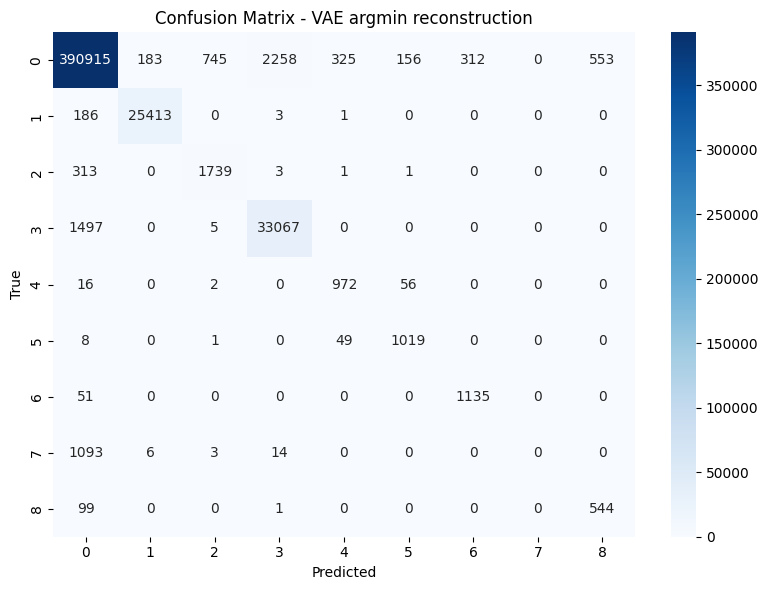


--- LightGBM output ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395447
           1       1.00      1.00      1.00     25603
           2       0.96      1.00      0.98      2057
           3       1.00      1.00      1.00     34569
           4       0.91      0.99      0.95      1046
           5       0.96      0.99      0.97      1077
           6       0.99      1.00      0.99      1186
           7       0.68      0.98      0.81      1116
           8       0.99      1.00      0.99       644

    accuracy                           1.00    462745
   macro avg       0.94      0.99      0.97    462745
weighted avg       1.00      1.00      1.00    462745



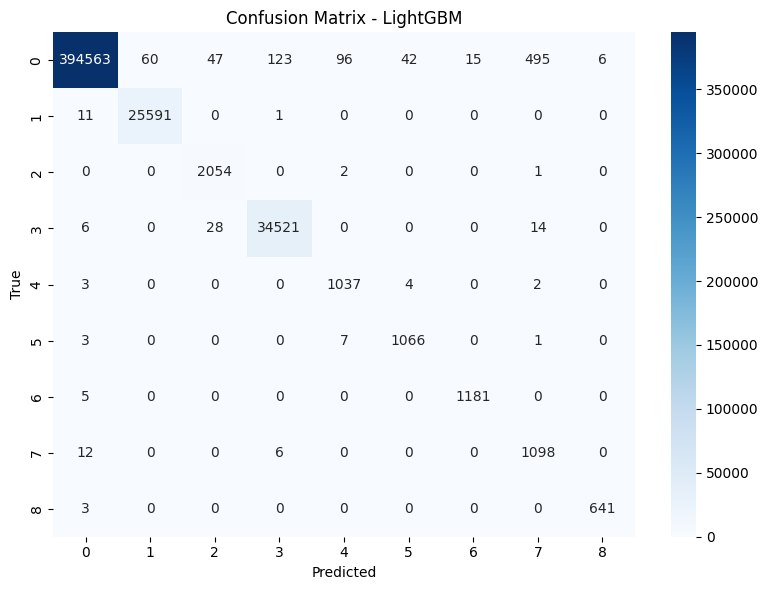


--- Combined system output ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395447
           1       1.00      1.00      1.00     25603
           2       0.97      1.00      0.99      2057
           3       1.00      1.00      1.00     34569
           4       0.92      0.99      0.95      1046
           5       0.96      0.99      0.98      1077
           6       0.99      1.00      0.99      1186
           7       0.87      0.87      0.87      1116
           8       0.99      0.99      0.99       644

    accuracy                           1.00    462745
   macro avg       0.97      0.98      0.98    462745
weighted avg       1.00      1.00      1.00    462745



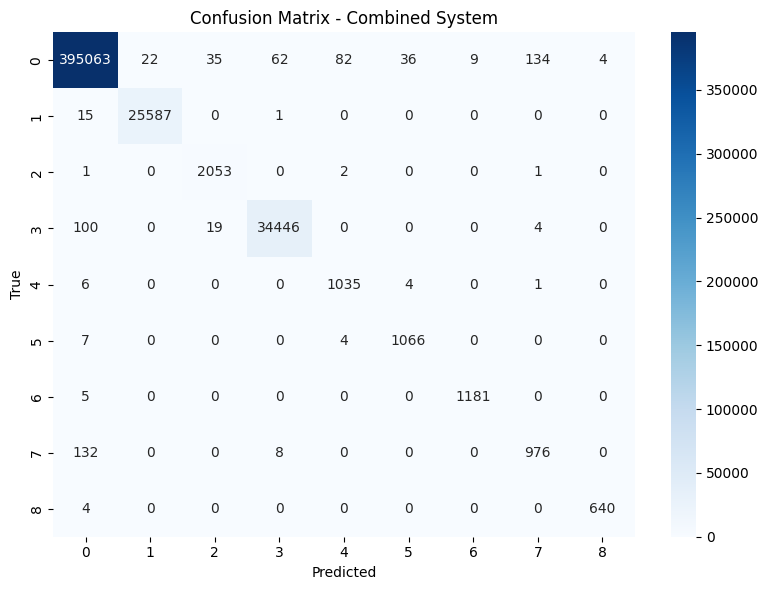

In [22]:
class_labels = sorted(np.unique(y_test))

print("\n--- VAE specialist output (not a true multiclass classifier anymore) ---")
print(classification_report(y_test, vae_pred, labels=class_labels, zero_division=0))
cm_vae = plot_confusion_matrix(
    y_test, vae_pred, class_labels, "Confusion Matrix - VAE argmin reconstruction"
)
plt.savefig("confusion_vae.png", dpi=150)
plt.show()

print("\n--- LightGBM output ---")
print(classification_report(y_test, lgb_pred, labels=class_labels, zero_division=0))
cm_lgb = plot_confusion_matrix(
    y_test, lgb_pred, class_labels, "Confusion Matrix - LightGBM"
)
plt.savefig("confusion_lgbm.png", dpi=150)
plt.show()

print("\n--- Combined system output ---")
print(classification_report(y_test, y_pred, labels=class_labels, zero_division=0))
cm_combined = plot_confusion_matrix(
    y_test, y_pred, class_labels, "Confusion Matrix - Combined System"
)
plt.savefig("confusion_combined.png", dpi=150)
plt.show()

In [23]:
metrics_vae = compute_metrics(y_test, vae_pred)
metrics_lgb = compute_metrics(y_test, lgb_pred)
metrics_combined = compute_metrics(y_test, y_pred)

df_summary = pd.DataFrame({
    "VAE": metrics_vae,
    "LightGBM": metrics_lgb,
    "Combined": metrics_combined
})

print("\n--- Summary Metrics ---")
print(df_summary.round(4))


--- Summary Metrics ---
                       VAE  LightGBM  Combined
Accuracy            0.9828    0.9979    0.9985
Macro Precision     0.7161    0.9428    0.9686
Macro Recall        0.8289    0.9945    0.9818
Macro F1            0.7638    0.9653    0.9750
Weighted Precision  0.9817    0.9982    0.9985
Weighted Recall     0.9828    0.9979    0.9985
Weighted F1         0.9821    0.9980    0.9985


**Probability-based evaluation**

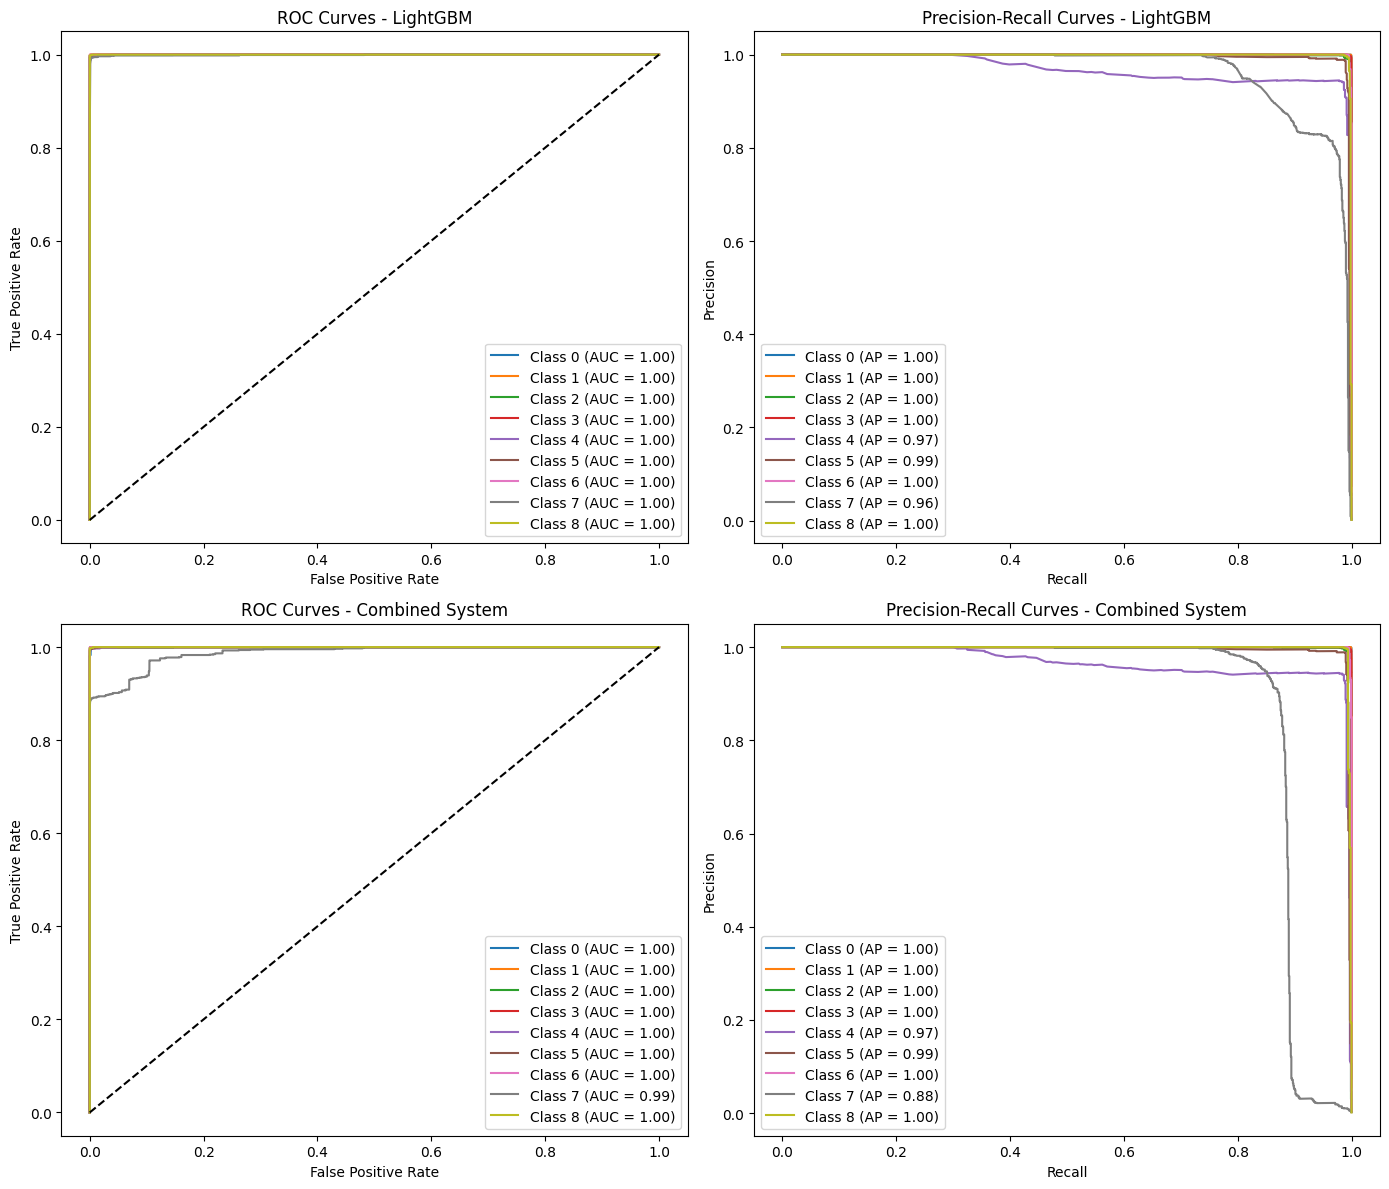

In [24]:
y_test_onehot = label_binarize(y_test, classes=class_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_roc_lgb, ax_pr_lgb, ax_roc_comb, ax_pr_comb = axes.flatten()

# LightGBM ROC / PR
for i, c in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], lgb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc_lgb.plot(fpr, tpr, label=f"Class {c} (AUC = {roc_auc:.2f})")

    precision, recall, _ = precision_recall_curve(y_test_onehot[:, i], lgb_proba[:, i])
    ap = average_precision_score(y_test_onehot[:, i], lgb_proba[:, i])
    ax_pr_lgb.plot(recall, precision, label=f"Class {c} (AP = {ap:.2f})")

ax_roc_lgb.plot([0, 1], [0, 1], "k--")
ax_roc_lgb.set_xlabel("False Positive Rate")
ax_roc_lgb.set_ylabel("True Positive Rate")
ax_roc_lgb.set_title("ROC Curves - LightGBM")
ax_roc_lgb.legend(loc="lower right")

ax_pr_lgb.set_xlabel("Recall")
ax_pr_lgb.set_ylabel("Precision")
ax_pr_lgb.set_title("Precision-Recall Curves - LightGBM")
ax_pr_lgb.legend(loc="lower left")

# Combined ROC / PR
for i, c in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc_comb.plot(fpr, tpr, label=f"Class {c} (AUC = {roc_auc:.2f})")

    precision, recall, _ = precision_recall_curve(y_test_onehot[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_onehot[:, i], y_proba[:, i])
    ax_pr_comb.plot(recall, precision, label=f"Class {c} (AP = {ap:.2f})")

ax_roc_comb.plot([0, 1], [0, 1], "k--")
ax_roc_comb.set_xlabel("False Positive Rate")
ax_roc_comb.set_ylabel("True Positive Rate")
ax_roc_comb.set_title("ROC Curves - Combined System")
ax_roc_comb.legend(loc="lower right")

ax_pr_comb.set_xlabel("Recall")
ax_pr_comb.set_ylabel("Precision")
ax_pr_comb.set_title("Precision-Recall Curves - Combined System")
ax_pr_comb.legend(loc="lower left")

plt.tight_layout()
plt.savefig("roc_pr_curves_lgbm_combined.png", dpi=150)
plt.show()

**VAE specialist evaluation**

In [25]:
print("\n--- VAE specialist diagnostics ---")

vae_auc_rows = []
for i, c in enumerate(class_labels):
    # Only evaluate if a dedicated VAE exists for this class
    if c not in hsystem.vaes or hsystem.vaes[c] is None:
        continue

    y_bin = (y_test == c).astype(int)
    score = -errors[:, i]   # lower reconstruction error means more likely "own class"

    try:
        auroc = roc_auc_score(y_bin, score)
    except ValueError:
        auroc = np.nan

    ap = average_precision_score(y_bin, score)
    vae_auc_rows.append({
        "Class": c,
        "AUROC(own-vs-rest)": auroc,
        "AP(own-vs-rest)": ap,
        "Mean error on own class": float(np.mean(errors[y_test == c, i])) if np.any(y_test == c) else np.nan,
        "Mean error off class": float(np.mean(errors[y_test != c, i])) if np.any(y_test != c) else np.nan,
    })

df_vae_auc = pd.DataFrame(vae_auc_rows)
print(df_vae_auc.round(4))


--- VAE specialist diagnostics ---
   Class  AUROC(own-vs-rest)  AP(own-vs-rest)  Mean error on own class  \
0      0              0.9437           0.9865                   0.0931   
1      1              0.9996           0.9965                   0.0579   
2      2              0.9955           0.7077                   0.0905   
3      3              0.9890           0.8579                   0.0665   
4      4              0.9976           0.8128                   0.0834   
5      5              0.9991           0.9486                   0.0501   
6      6              0.9986           0.8972                   0.1054   
7      8              0.9938           0.4553                   0.0882   

   Mean error off class  
0                1.3798  
1                6.1582  
2                9.0613  
3                4.7809  
4                4.5747  
5                4.9686  
6                8.2783  
7                6.1023  


**Routing analysis**


--- Routing per True Class (%) ---
routed_to   abstain->lgbm   lgbm    vae
true_class                             
0                    0.08  99.67   0.26
1                    0.01  99.96   0.03
2                    0.15  99.81   0.05
3                    0.06  99.60   0.33
4                   45.22  54.49   0.29
5                    7.06  92.57   0.37
6                    0.25  99.66   0.08
7                    0.63  88.08  11.29
8                    0.00  99.84   0.16


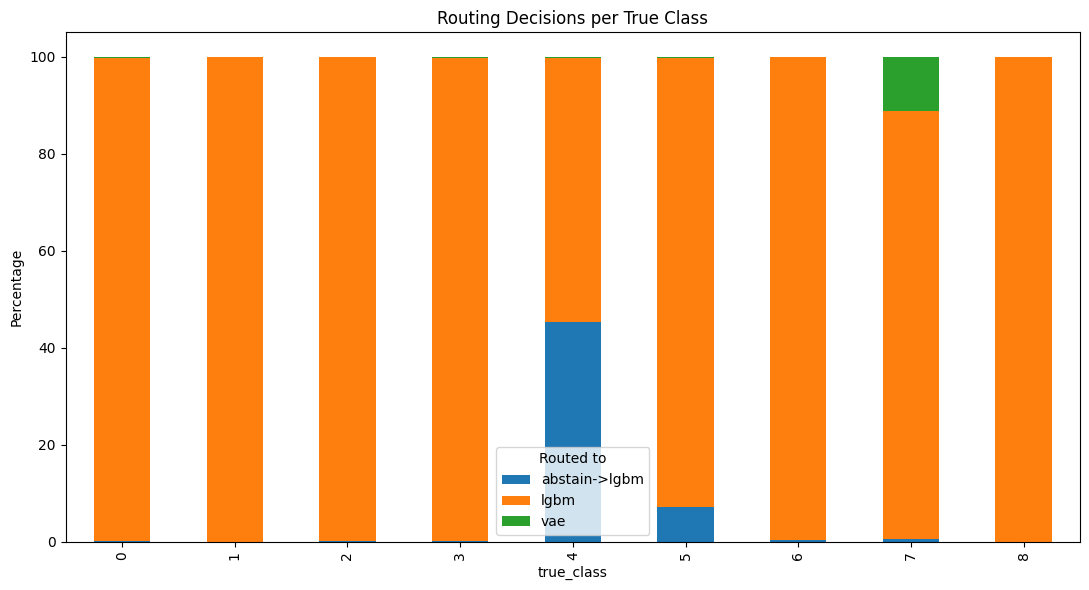


--- Overall routing share ---
routed_to
lgbm             99.53
vae               0.28
abstain->lgbm     0.19
Name: proportion, dtype: float64


In [26]:
route_df = pd.DataFrame({
    "true_class": y_test,
    "routed_to": stage
})

route_counts = route_df.groupby(["true_class", "routed_to"]).size().unstack(fill_value=0)
route_percent = route_counts.div(route_counts.sum(axis=1), axis=0) * 100

print("\n--- Routing per True Class (%) ---")
print(route_percent.round(2))

ax = route_percent.plot(kind="bar", stacked=True, figsize=(11, 6))
ax.set_ylabel("Percentage")
ax.set_title("Routing Decisions per True Class")
ax.legend(title="Routed to")
plt.tight_layout()
plt.savefig("routing_per_class.png", dpi=150)
plt.show()

print("\n--- Overall routing share ---")
print(route_df["routed_to"].value_counts(normalize=True).mul(100).round(2))

**Gate quality analysis**

In [27]:
if hsystem.meta_gate is not None:
    gate_df = pd.DataFrame({
        "true_class": y_test,
        "gate_choice": gate_name[gate_choice],
        "lgb_correct": (lgb_pred == y_test),
        "vae_correct": (vae_pred == y_test),
        "final_correct": (y_pred == y_test),
        "stage": stage
    })

    print("\n--- Gate choice counts ---")
    print(gate_df["gate_choice"].value_counts())

    print("\n--- Accuracy by gate choice ---")
    print(gate_df.groupby("gate_choice")["final_correct"].mean().sort_values(ascending=False).round(4))

    print("\n--- Coverage by gate choice ---")
    print(gate_df["gate_choice"].value_counts(normalize=True).mul(100).round(2))

    # Gate confusion-like summary: where the system chose VAE but VAE was wrong
    vae_route_mask = (stage == "vae")
    if np.any(vae_route_mask):
        print("\n--- VAE-routed sample quality ---")
        print("VAE-routed accuracy:", accuracy_score(y_test[vae_route_mask], y_pred[vae_route_mask]))
        print("VAE-routed count:", int(np.sum(vae_route_mask)))

    lgb_route_mask = np.logical_or(stage == "lgbm", stage == "abstain->lgbm")
    if np.any(lgb_route_mask):
        print("\n--- LightGBM-routed sample quality ---")
        print("LGBM-routed accuracy:", accuracy_score(y_test[lgb_route_mask], y_pred[lgb_route_mask]))
        print("LGBM-routed count:", int(np.sum(lgb_route_mask)))


--- Gate choice counts ---
gate_choice
LightGBM         460577
VAE                1285
Abstain->LGBM       883
Name: count, dtype: int64

--- Accuracy by gate choice ---
gate_choice
LightGBM         0.9994
VAE              0.8148
Abstain->LGBM    0.8097
Name: final_correct, dtype: float64

--- Coverage by gate choice ---
gate_choice
LightGBM         99.53
VAE               0.28
Abstain->LGBM     0.19
Name: proportion, dtype: float64

--- VAE-routed sample quality ---
VAE-routed accuracy: 0.8147859922178988
VAE-routed count: 1285

--- LightGBM-routed sample quality ---
LGBM-routed accuracy: 0.9990031638711915
LGBM-routed count: 461460


**Reconstruction error distributions**

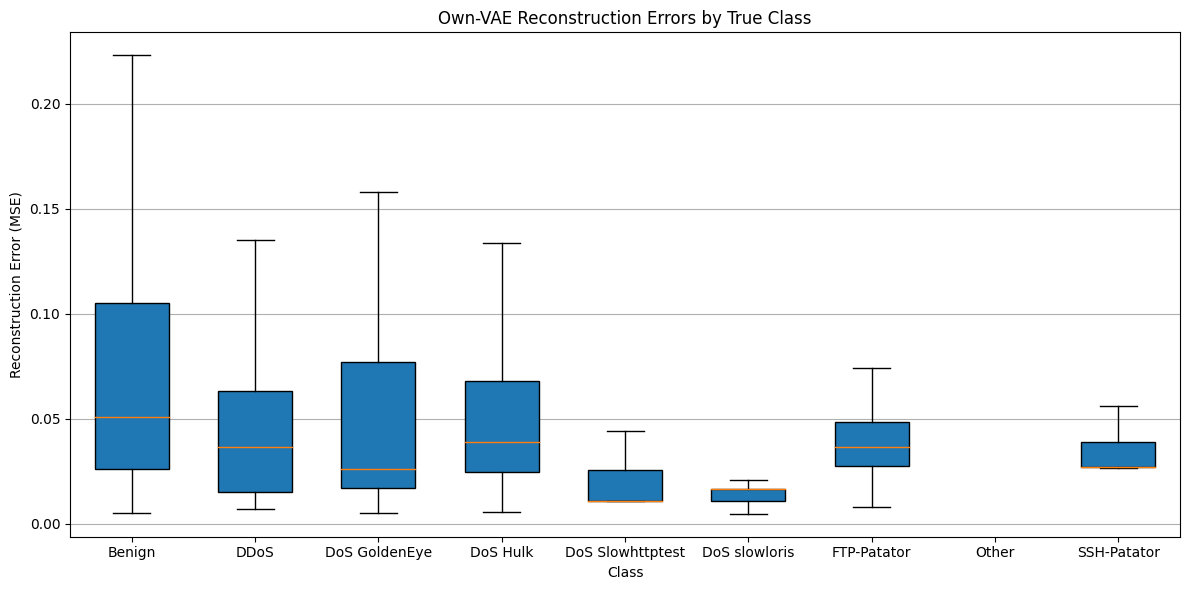

In [28]:
own_errors = []
for i, c in enumerate(class_labels):
    if c in hsystem.vaes and hsystem.vaes[c] is not None:
        mask = (y_test == c)
        if np.any(mask):
            own_errors.append(errors[mask, i])
        else:
            own_errors.append(np.array([]))
    else:
        own_errors.append(np.array([]))

plt.figure(figsize=(12, 6))
bp = plt.boxplot(
    own_errors,
    positions=np.arange(len(class_labels)),
    widths=0.6,
    patch_artist=True,
    showfliers=False
)
plt.xticks(np.arange(len(labels)), labels)
plt.xlabel("Class")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Own-VAE Reconstruction Errors by True Class")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("error_distribution_boxplot.png", dpi=150)
plt.show()

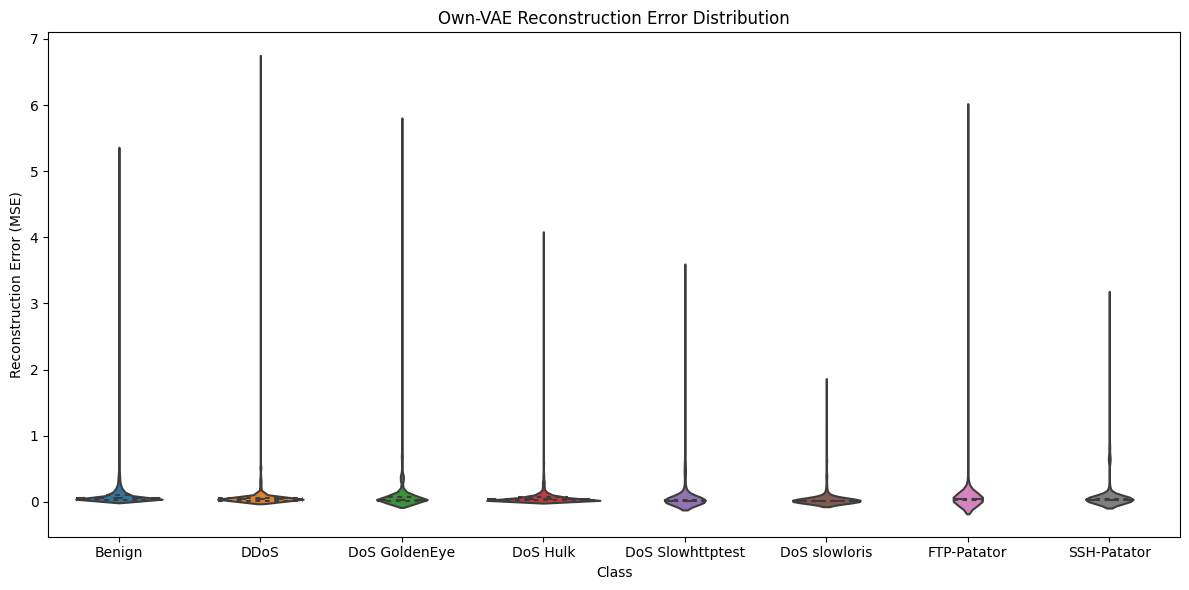

In [29]:
violin_data = [arr for arr in own_errors if len(arr) > 0]
violin_labels = [str(c) for i, c in enumerate(labels) if len(own_errors[i]) > 0]

plt.figure(figsize=(12, 6))
sns.violinplot(data=violin_data, inner="quartile")
plt.xticks(ticks=range(len(violin_labels)), labels=violin_labels)
plt.xlabel("Class")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Own-VAE Reconstruction Error Distribution")
plt.tight_layout()
plt.savefig("error_violin.png", dpi=150)
plt.show()

# **Save artifacts**

In [30]:
import os
import json
import joblib
import numpy as np
from pathlib import Path

def save_full_artifacts(
    system,
    out_dir,
    scaler=None,
    label_encoder=None,
    feature_names=None,
    metrics=None,
    notes=None,
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1) Save the hierarchical model itself
    model_dir = out_dir / "model"
    system.save(str(model_dir))

    # 2) Save preprocessing artifacts if they exist
    if scaler is not None:
        joblib.dump(scaler, out_dir / "scaler.joblib")

    if label_encoder is not None:
        joblib.dump(label_encoder, out_dir / "label_encoder.joblib")

    # 3) Save metadata needed to reproduce inference
    meta = {
        "input_dim": system.input_dim,
        "latent_dim": system.latent_dim,
        "n_classes": system.n_classes,
        "class_ids": system.class_ids.tolist() if system.class_ids is not None else [],
        "open_set_class_ids": list(system.open_set_class_ids) if hasattr(system, "open_set_class_ids") else [],
        "use_latents": getattr(system, "use_latents", False),
        "augmentation_noise_std": getattr(system, "augmentation_noise_std", None),
        "notes": notes,
    }

    if feature_names is not None:
        meta["feature_names"] = list(feature_names)

    if metrics is not None:
        meta["metrics"] = metrics

    with open(out_dir / "metadata.json", "w") as f:
        json.dump(meta, f, indent=4)

    # 4) Save class IDs separately for convenience
    if system.class_ids is not None:
        np.save(out_dir / "class_ids.npy", system.class_ids)

    return str(out_dir)


def load_full_artifacts(out_dir):
    out_dir = Path(out_dir)

    system = HierarchicalVAEGatedSystem.load(str(out_dir / "model"))

    scaler_path = out_dir / "scaler.joblib"
    label_encoder_path = out_dir / "label_encoder.joblib"
    metadata_path = out_dir / "metadata.json"

    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    label_encoder = joblib.load(label_encoder_path) if label_encoder_path.exists() else None

    metadata = None
    if metadata_path.exists():
        with open(metadata_path, "r") as f:
            metadata = json.load(f)

    return system, scaler, label_encoder, metadata

In [31]:
# after training and evaluation
save_dir = "artifacts/ghvae_ids_v1"

summary_metrics = {
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
}

save_full_artifacts(
    system=hsystem,
    out_dir=save_dir,
    scaler=scaler,                 # your fitted scaler, if used
    label_encoder=Label_Encoder,   # your fitted label encoder, if used
    feature_names=feature_names,   # optional
    metrics=summary_metrics,
    notes="LightGBM main classifier, VAE specialist, learned meta-gate."
)

'artifacts/ghvae_ids_v1'

# **Loading**

In [32]:
def load_full_artifacts(out_dir):
    out_dir = Path(out_dir)

    system = HierarchicalVAEGatedSystem.load(str(out_dir / "model"))

    scaler_path = out_dir / "scaler.joblib"
    label_encoder_path = out_dir / "label_encoder.joblib"
    metadata_path = out_dir / "metadata.json"

    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    label_encoder = joblib.load(label_encoder_path) if label_encoder_path.exists() else None

    metadata = None
    if metadata_path.exists():
        with open(metadata_path, "r") as f:
            metadata = json.load(f)

    return system, scaler, label_encoder, metadata